In [ ]:
!pip install pnadc pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pnadc

In [ ]:
cols = [
  'UF',
  'V2007',
  'V2010',
  'VD3004',
  'VD4019',
  'V1028',
  'VD4002',
  ]

cesto_de_dados = []

anos = [2022, 2023, 2024]

for ano in anos:
  df = pnadc.get(year=ano, quarter=4, keep_columns=cols)
  df['Ano'] = ano
  cesto_de_dados.append(df)


Chaves_PNADC.pdf download is complete!
Definicao_variaveis_derivadas_PNADC_20200211.pdf download is complete!
Deflatores.zip download is complete!
Unziping Deflatores.zip
Unzip complete
Dicionario_e_input_20221031.zip download is complete!
Unziping Dicionario_e_input_20221031.zip
Unzip complete
Estrutura_Atividade_CNAE_Domiciliar_2_0.xls download is complete!
Estrutura_Ocupacao_COD.xls download is complete!
Grupamentos_ocupacionais_atividades_PNADC.pdf download is complete!
PNADcIBGE_Deflator_Trimestral.pdf download is complete!
Variaveis_PNADC_Trimestral.xls download is complete!
PNADC_042022_20250815.zip download is complete!
Unziping PNADC_042022_20250815.zip
Unzip complete
Building PNADC_042022.txt
Multiprocessing chunks


100%|██████████| 24/24 [04:11<00:00, 10.48s/it]


Done!
Chaves_PNADC.pdf download is complete!
Definicao_variaveis_derivadas_PNADC_20200211.pdf download is complete!
Deflatores.zip download is complete!
Unziping Deflatores.zip
Unzip complete
Dicionario_e_input_20221031.zip download is complete!
Unziping Dicionario_e_input_20221031.zip
Unzip complete
Estrutura_Atividade_CNAE_Domiciliar_2_0.xls download is complete!
Estrutura_Ocupacao_COD.xls download is complete!
Grupamentos_ocupacionais_atividades_PNADC.pdf download is complete!
PNADcIBGE_Deflator_Trimestral.pdf download is complete!
Variaveis_PNADC_Trimestral.xls download is complete!
PNADC_042023_20250815.zip download is complete!
Unziping PNADC_042023_20250815.zip
Unzip complete
Building PNADC_042023.txt
Multiprocessing chunks


100%|██████████| 24/24 [03:46<00:00,  9.42s/it]


Done!
Chaves_PNADC.pdf download is complete!
Definicao_variaveis_derivadas_PNADC_20200211.pdf download is complete!
Deflatores.zip download is complete!
Unziping Deflatores.zip
Unzip complete
Dicionario_e_input_20221031.zip download is complete!
Unziping Dicionario_e_input_20221031.zip
Unzip complete
Estrutura_Atividade_CNAE_Domiciliar_2_0.xls download is complete!
Estrutura_Ocupacao_COD.xls download is complete!
Grupamentos_ocupacionais_atividades_PNADC.pdf download is complete!
PNADcIBGE_Deflator_Trimestral.pdf download is complete!
Variaveis_PNADC_Trimestral.xls download is complete!
PNADC_042024_20250815.zip download is complete!
Unziping PNADC_042024_20250815.zip
Unzip complete
Building PNADC_042024.txt
Multiprocessing chunks


100%|██████████| 24/24 [04:03<00:00, 10.13s/it]

Done!


In [ ]:
# dicionario para substituir os codigos
dicionario_escolaridade = {
    1: 'Sem instrução',
    2: 'Fundamental incompleto',
    3: 'Fundamental completo',
    4: 'Médio incompleto',
    5: 'Médio completo',
    6: 'Superior incompleto',
    7: 'Superior completo'
}

dicionario_sexo = {
    1: 'Homem',
    2: 'Mulher'
}

dicionario_raca = {
    1: 'Branca',
    2: 'Preta',
    3: 'Amarela',
    4: 'Parda',
    5: 'Indígena',
    9: 'Ignorado'
}

dicionario_uf = {
    11: 'Rondônia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Pará',
    16: 'Amapá', 17: 'Tocantins', 21: 'Maranhão', 22: 'Piauí',
    23: 'Ceará', 24: 'Rio Grande do Norte', 25: 'Paraíba', 26: 'Pernambuco',
    27: 'Alagoas', 28: 'Sergipe', 29: 'Bahia',31: 'Minas Gerais',
    32: 'Espírito Santo', 33: 'Rio de Janeiro', 35: 'São Paulo',
    41: 'Paraná', 42: 'Santa Catarina', 43: 'Rio Grande do Sul',
    50: 'Mato Grosso do Sul', 51: 'Mato Grosso',
    52: 'Goiás', 53: 'Distrito Federal'
}

mapa_colunas = {
    'VD4019': 'Renda',
    'V1028': 'Peso'
}

dicionario_ocupacao = {
    1: 'Ocupado'
}


In [ ]:
# função para organizar os dados automaticamente
def tratar_dados(df):
    df = df.copy()

    df['Escolaridade'] = df['VD3004'].map(dicionario_escolaridade)
    df['Sexo'] = df['V2007'].map(dicionario_sexo)
    df['Cor'] = df['V2010'].map(dicionario_raca)
    df['UF'] = df['UF'].map(dicionario_uf)
    df['Status_Ocupacao'] = df['VD4002'].map(dicionario_ocupacao).fillna('Desocupado')

    return df.rename(columns=mapa_colunas)

In [ ]:
df_final = pd.concat(cesto_de_dados, ignore_index=True)

In [ ]:
# tratar os dados e apagar dados NaN
df_emprego = tratar_dados(df)
df_final_tratado = tratar_dados(df_final)
df_clean = tratar_dados(df.dropna(subset=['VD4019']))

In [ ]:
df_final_tratado.head()

,UF,V2007,V2010,VD3004,Renda,Peso,VD4002,Ano,Escolaridade,Sexo,Cor,Status_Ocupacao
0,Rondônia,1.0,4.0,5.0,2500.0,226.139635,1.0,2022,Médio completo,Homem,Parda,Ocupado
1,Rondônia,2.0,4.0,5.0,NaN,226.139635,NaN,2022,Médio completo,Mulher,Parda,Desocupado
2,Rondônia,2.0,4.0,7.0,3500.0,127.002699,1.0,2022,Superior completo,Mulher,Parda,Ocupado
3,Rondônia,2.0,4.0,5.0,NaN,221.114789,NaN,2022,Médio completo,Mulher,Parda,Desocupado
4,Rondônia,2.0,4.0,NaN,NaN,221.114789,NaN,2022,NaN,Mulher,Parda,Desocupado


In [ ]:
filtro = df_emprego['Escolaridade'].isin(['Médio completo', 'Superior completo'])
df_analise = df_emprego[filtro]
tabela = pd.crosstab(df_analise['Escolaridade'], df_analise['Status_Ocupacao'])

print(tabela)

Status_Ocupacao    Desocupado  Ocupado
Escolaridade                          
Médio completo          38309    73436
Superior completo       12817    45023


In [ ]:
df_clean.head()

,UF,V2007,V2010,VD3004,Renda,Peso,VD4002,Ano,Escolaridade,Sexo,Cor,Status_Ocupacao
1,Rondônia,1.0,4.0,5.0,1412.0,235.636327,1.0,2024,Médio completo,Homem,Parda,Ocupado
2,Rondônia,2.0,4.0,5.0,1412.0,178.784306,1.0,2024,Médio completo,Mulher,Parda,Ocupado
3,Rondônia,1.0,4.0,5.0,2000.0,178.784306,1.0,2024,Médio completo,Homem,Parda,Ocupado
6,Rondônia,2.0,2.0,7.0,2180.0,154.522051,1.0,2024,Superior completo,Mulher,Preta,Ocupado
7,Rondônia,2.0,4.0,5.0,1412.0,154.522051,1.0,2024,Médio completo,Mulher,Parda,Ocupado


In [ ]:
renda_por_educacao = df_clean.groupby('Escolaridade')['Renda'].mean()

Escolaridade
Fundamental completo      2027.212473
Fundamental incompleto    1723.454482
Médio completo            2379.483928
Médio incompleto          1849.326342
Sem instrução             1412.494493
Superior completo         6254.421877
Superior incompleto       2907.202629
Name: Renda, dtype: float64


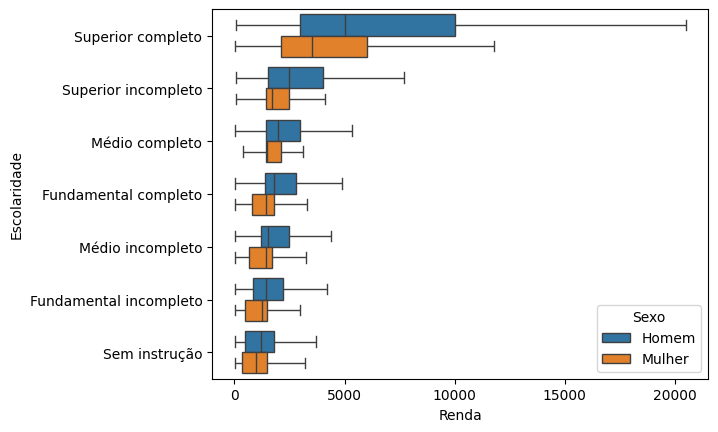

In [ ]:
df_grafico = renda_por_educacao.reset_index()
ordem_salarios = df_grafico.sort_values(by='Renda', ascending=False)['Escolaridade']
sns.boxplot(data=df_clean, y='Escolaridade', x='Renda', order=ordem_salarios, showfliers=False, hue='Sexo')
print(renda_por_educacao)

Cor
Amarela     4745.201536
Branca      3961.870116
Ignorado    2989.894737
Parda       2389.095621
Indígena    2323.585907
Preta       2309.360115
Name: Renda, dtype: float64


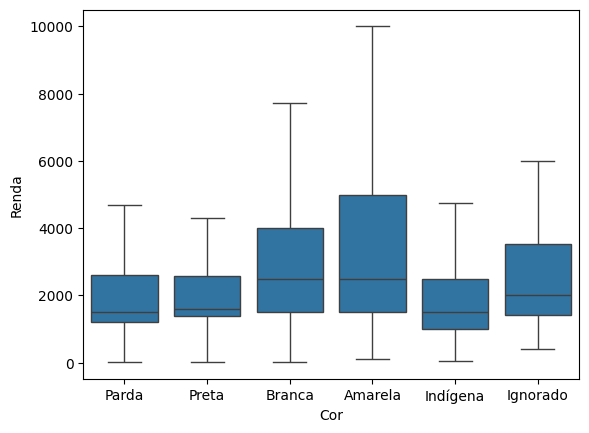

In [ ]:
renda_por_cor = df_clean.groupby('Cor')['Renda'].mean().sort_values(ascending=False)
sns.boxplot(data=df_clean, y='Renda', x='Cor', showfliers=False)
print(renda_por_cor)

In [ ]:
tabela_comparativa = df_clean.groupby(['Escolaridade', 'Sexo'])['Renda'].mean().unstack()
print(tabela_comparativa)

Sexo                          Homem       Mulher
Escolaridade                                    
Fundamental completo    2289.791729  1534.607279
Fundamental incompleto  1911.019335  1259.122668
Médio completo          2755.919517  1906.570164
Médio incompleto        2080.552519  1407.912678
Sem instrução           1456.963988  1279.606881
Superior completo       7860.134105  5059.957619
Superior incompleto     3610.329853  2267.421276


In [ ]:
df_final_tratado.to_csv('pnadc_2022_a_2024.csv', index=False)